In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split 
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
import logging

# Disable matplotlib warnings (replacement for matplotlib_axes_logger)
logging.getLogger('matplotlib').setLevel(logging.ERROR)


# Create dataset as a circuler shape To understand the kernel trick of SVM

In [7]:
from sklearn.datasets import make_circles
x,y=make_circles(n_samples=100,factor=0.5, noise=0.05 , random_state=42)



In [8]:
x

array([[-0.23609814, -0.4675    ],
       [ 0.48869037,  0.24924534],
       [-0.39392915,  0.32374486],
       [ 0.76420024, -0.59338464],
       [ 0.80241569, -0.74074202],
       [ 0.23488158, -0.89596143],
       [-0.90688223,  0.28391018],
       [-0.38816624, -0.29794857],
       [ 0.33240673,  0.98786263],
       [ 0.96101491, -0.04219482],
       [-0.64495068,  0.72223536],
       [-0.80149254, -0.59345631],
       [-0.35261517,  0.0730904 ],
       [-0.57492919, -0.82313077],
       [ 0.19814375, -0.36116696],
       [ 0.95745271,  0.52294033],
       [-0.48140439, -0.0178351 ],
       [-0.51480768, -0.14015324],
       [-0.01133069,  0.98658435],
       [-0.68083656, -0.69503173],
       [ 0.36580635,  0.27590372],
       [ 0.06759942, -0.5118016 ],
       [-0.94961864, -0.19089944],
       [ 0.49231155, -0.86966009],
       [-0.42998185,  0.48945672],
       [-0.36383028,  0.99680073],
       [ 0.27571396, -0.97674589],
       [ 0.45321948, -0.31380268],
       [ 0.39264238,

In [9]:
y

array([1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1])

# show raw dataset (circle)

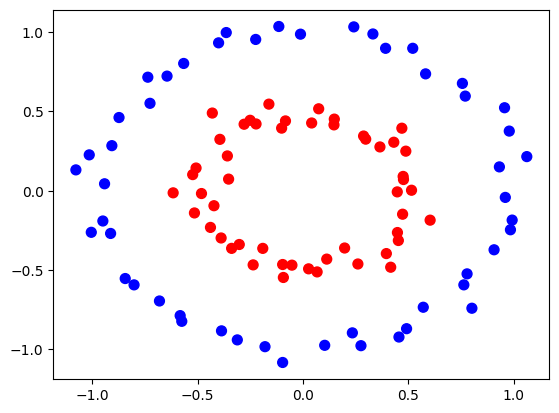

In [11]:
plt.scatter(x[:,0],x[:,1],c=y,s=50,cmap='bwr')

# now we  try to use SVM to classify the data

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20)

In [16]:
classifier=SVC(kernel="linear")
classifier.fit(x_train,y_train.ravel())
y_pred=classifier.predict(x_test)


In [17]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.25

In [20]:
zero_one_colormap = ListedColormap(('blue', 'red'))

def plot_decision_boundry(x, y, clf):
    x_set, y_set = x, y
    x1, x2 = np.meshgrid(
        np.arange(start=x_set[:,0].min()-1, stop=x_set[:,0].max()+1, step=0.01),
        np.arange(start=x_set[:,1].min()-1, stop=x_set[:,1].max()+1, step=0.01)
    )

    plt.contourf(
        x1, x2,
        clf.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
        alpha=0.75, cmap=zero_one_colormap
    )
    plt.xlim(x1.min(), x1.max())
    plt.ylim(x2.min(), x2.max())

    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(
            x_set[y_set==j, 0], x_set[y_set==j, 1],
            c=[zero_one_colormap(i)], label=f"Class {j}"
        )

    plt.title("SVM Decision Boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.show()


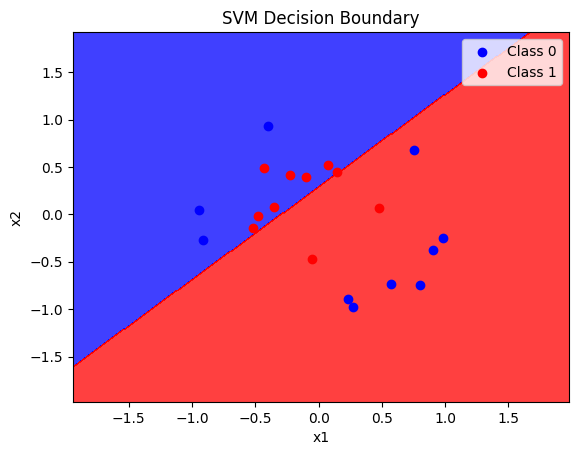

In [21]:
plot_decision_boundry(x_test,y_test,classifier)

# function for 3d plot

In [22]:
def plot_3d_plot(x,y):
    r=np.exp(-(x**2).sum(1))
    ax=plt.subplot(projection='3d')
    ax.scatter3D(x[:,0],x[:,1],r,c=y,s=100 ,cmap='bwr')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('y')
    return ax;

<Axes3D: xlabel='x1', ylabel='x2', zlabel='y'>

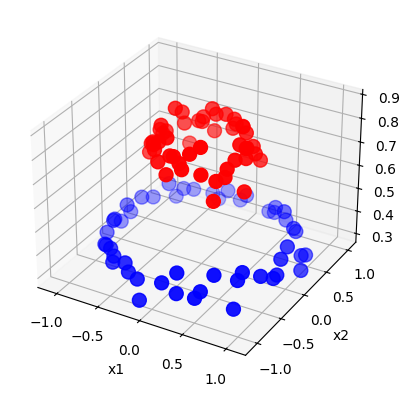

In [23]:
plot_3d_plot(x,y)